In [20]:
from src.runner import preprocess
preprocess()

Processing Center for Advanced Life Cycle Engineering cells: 100%|██████████| 7/7 [00:05<00:00,  1.25it/s]


0 processed, 7 skipped



Processing Hawaii Natural Energy Institute cells: 100%|██████████| 15/15 [00:12<00:00,  1.21it/s]


0 processed, 15 skipped



Processing Oxford cells: 100%|██████████| 8/8 [00:04<00:00,  1.74it/s]


...

230 processed, 23 skipped



Processing Sandia National Lab cells: 100%|██████████| 32/32 [00:13<00:00,  2.44it/s]


74 processed, 12 skipped



Processing Underwriters Lab - Purdue University cells: 100%|██████████| 22/22 [00:09<00:00,  2.26it/s]

21 processed, 1 skipped



In [8]:
# ===== SET HYPERPARAMETERS =======
num_epochs = 3
window_size = 500
window_skip = 300

In [9]:
# ===== INITIALIZE DATALOADERS =======
from src.data import get_divided_loaders, get_divided_loaders_from

healthy_train_loader, healthy_test_loader = get_divided_loaders_from(window_size=window_size, window_skip=window_skip, preload=True)
_, unhealthy_test_loader = get_divided_loaders(test_size=1.0, window_size=window_size, window_skip=window_skip, preload=True, configfile='unhealthy')

Checking attributes: 100%|██████████| 333/333 [00:00<00:00, 1408.27it/s]


In [10]:
# ===== INITIALIZE TRANSFORMER AUTOENCODER =======
from src.training import *
from src.models import TransformerAutoencoder
import pickle

DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Using device:", DEVICE)

model_filename = f'results/trained_models/{num_epochs}epoch_0.8healthy_{window_size}window_{window_skip}step.pkl'
print("Model:", model_filename)

retrain = False # NOTE: THIS DETERMINES WHETHER YOU LOAD AN EXISTING MODEL OR TRAIN & SAVE A NEW ONE
if retrain:
    transformer_model = TransformerAutoencoder(
        input_dim=1,      # number of features per timestep
        model_dim=64,     # hidden embedding dimension
        num_heads=4,      # parallel attention heads
        num_layers=2      # stacked encoder/decoder layers
    )

    # took 9m 13s to train 1 epoch with 80% of healthy data files
    transformer_model.to(DEVICE)
    for epoch in range(1,num_epochs+1):
        print(f"Epoch {epoch}/{num_epochs}")
        train_loss = train_epoch(transformer_model, healthy_train_loader, DEVICE)
        print(f" Train loss: {train_loss:.6f}")

    with open(model_filename, 'wb') as file:
        pickle.dump(transformer_model, file)

else:
    transformer_model = TransformerAutoencoder.load(model_filename)

Using device: mps
Model: results/trained_models/3epoch_0.8healthy_500window_300step.pkl


Generating plots: 100%|██████████| 18/18 [00:03<00:00,  5.84it/s]


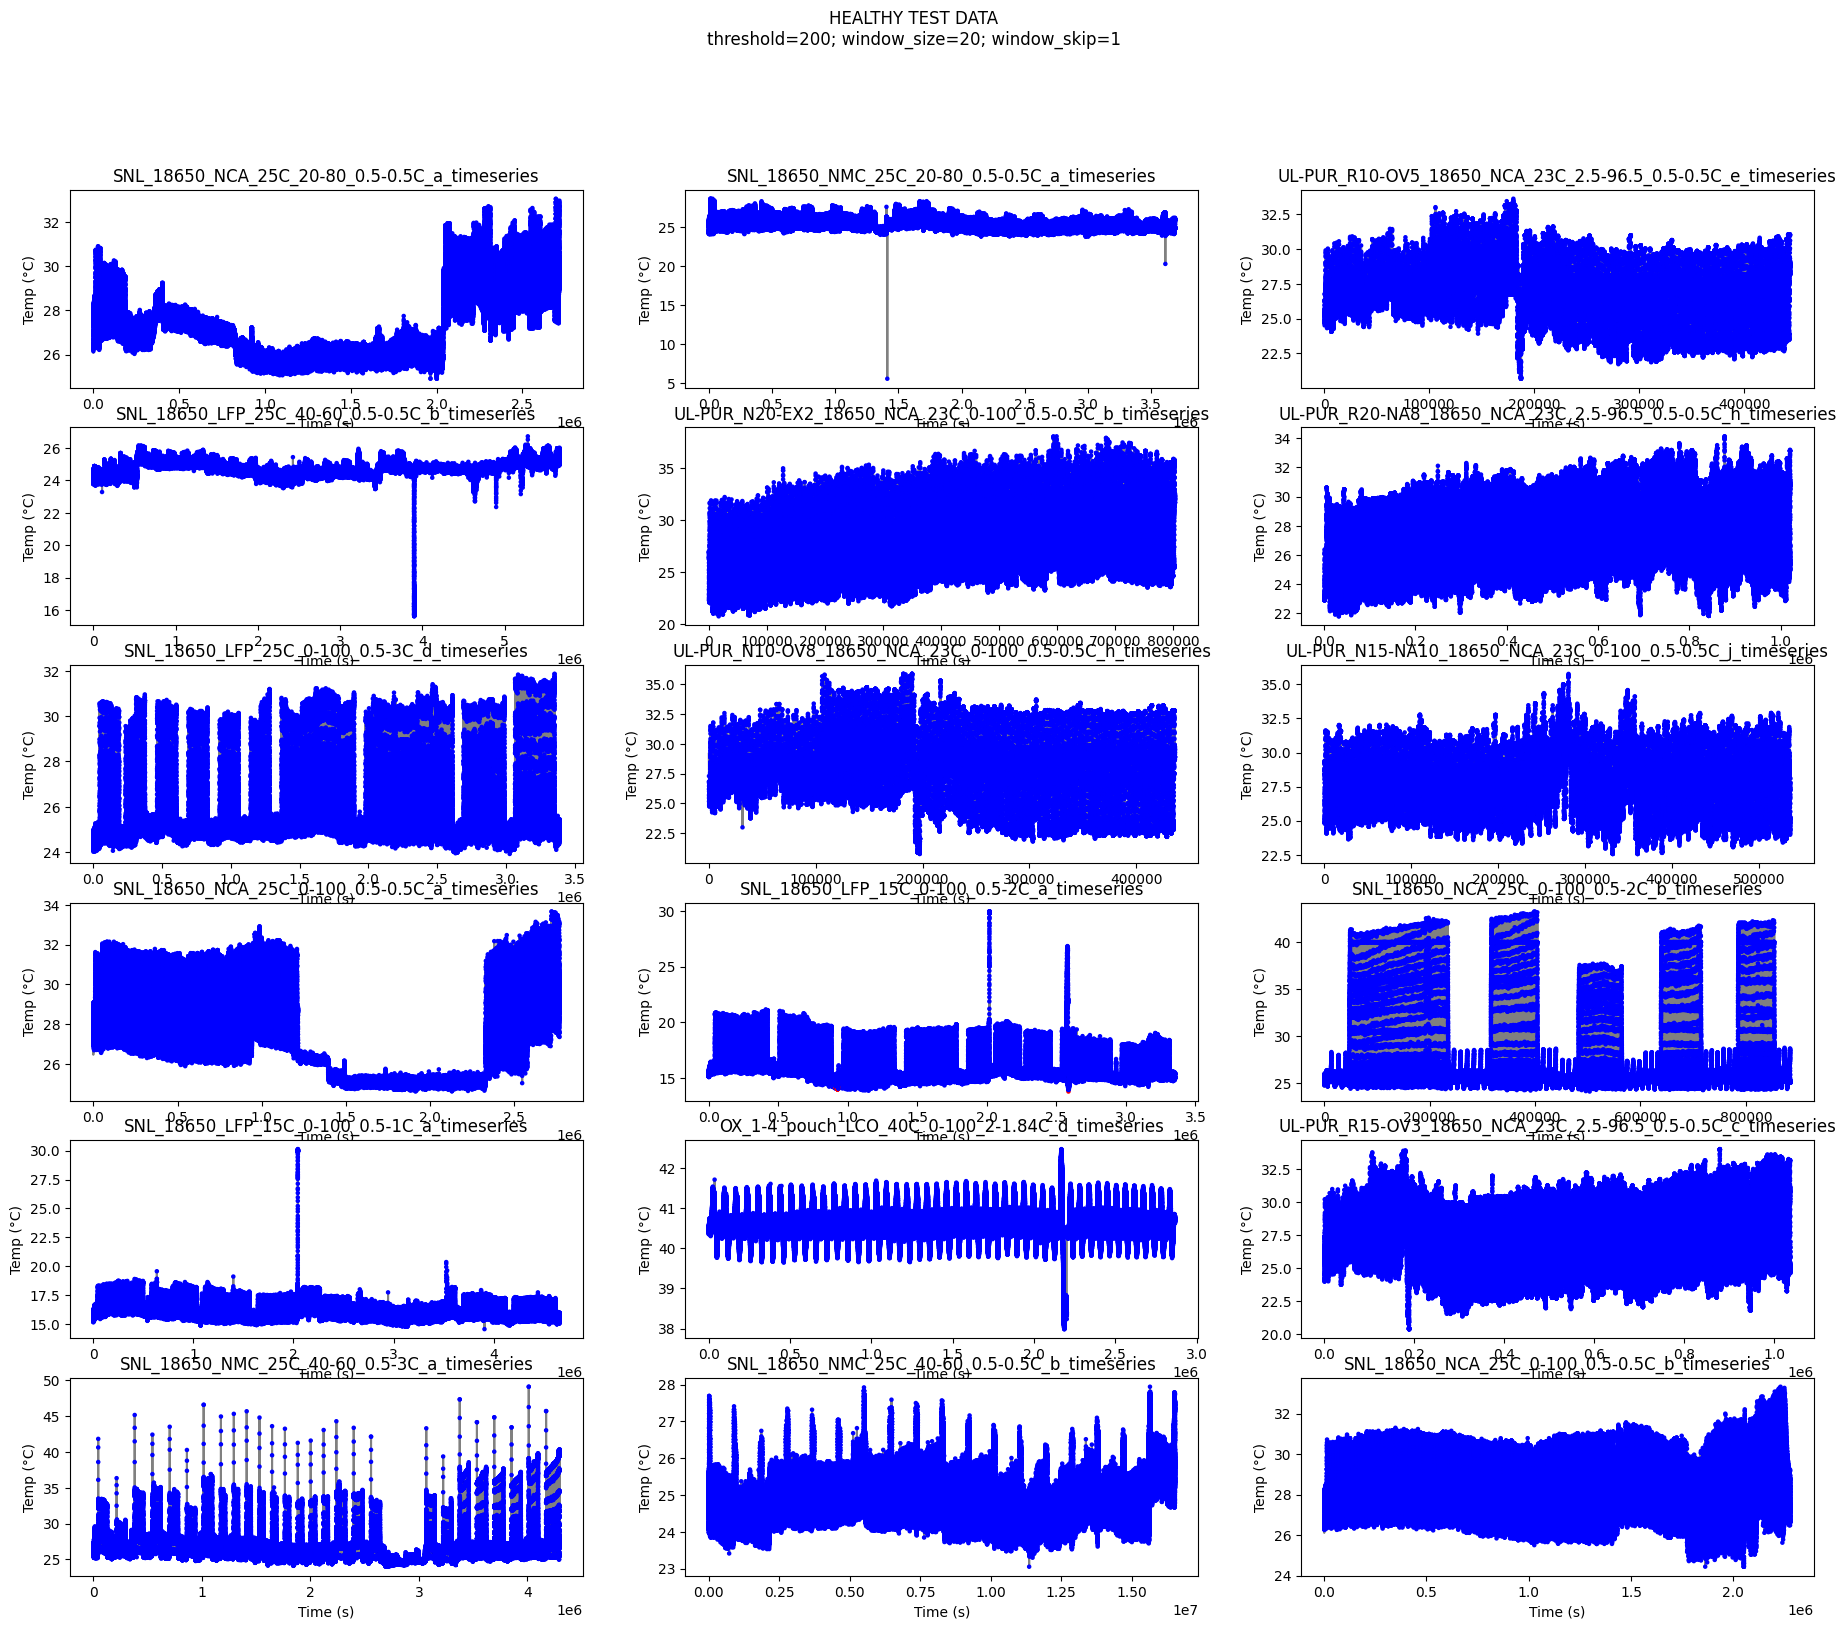

In [11]:
from src.validation import *

THRESHOLD = 200

plot_multiple_evals_on_temp(
    err_file="results/reconstruction_errs/reconstruction_errs_healthy_test.json",
    model=transformer_model,
    title="HEALTHY TEST DATA",
    threshold=THRESHOLD
)

In [12]:
import pandas as pd

ornl_findings = pd.read_csv('results/findings_with_ohs.csv')

ohs_scores = ["Very Low", "Low", "Moderate", "High", "Very High"]
ohs_to_int = {ohs: idx for idx, ohs in enumerate(ohs_scores)}

ornl_summary = (
    ornl_findings
    .groupby(["obs_int", "ohs"], as_index=True)
    .agg(
        ohs_int=("ohs_int", "first"),
        instances=("max_err", "count"),
        min_err=("max_err", "min"),
        max_err=("max_err", "max"),
        median_err=("max_err", "median"),
        min_temp=("max_temp", "min"),
        max_temp=("max_temp", "max"),
        median_temp=("max_temp", "median"),
    )
)
ornl_summary

ohs_int  instances       min_err       max_err  \
obs_int ohs                                                         
-1      High             3          1  14852.215820  14852.215820   
        Moderate         2          1    639.882446    639.882446   
 1      Very Low         0          1     30.139027     30.139027   
 2      Low              1          8    406.652771   4422.933594   
        Moderate         2          6    842.892578   4167.034180   
 3      Moderate         2          8    350.077301  11049.041992   
 4      Moderate         2          3   1011.570312   5043.870117   
 7      Very High        4          3  14852.215820  14852.215820   

                     median_err   min_temp   max_temp  median_temp  
obs_int ohs                                                         
-1      High       14852.215820  150.24270  150.24270    150.24270  
        Moderate     639.882446   53.68330   53.68330     53.68330  
 1      Very Low      30.139027   27.37152   27.37152     27.37152  
 2      Low         2714.863403   48.74900   95.38100     80.85700  
        Moderate    4044.095215   57.59005   93.19600     92.51650  
 3      Moderate    1817.842529   47.17092  133.97980     71.26200  
 4      Moderate    1019.681641   60.47536   99.75447     76.32388  
 7      Very High  14852.215820  150.24270  150.24270    150.24270

Generating plots: 100%|██████████| 3/3 [00:00<00:00, 330.47it/s]


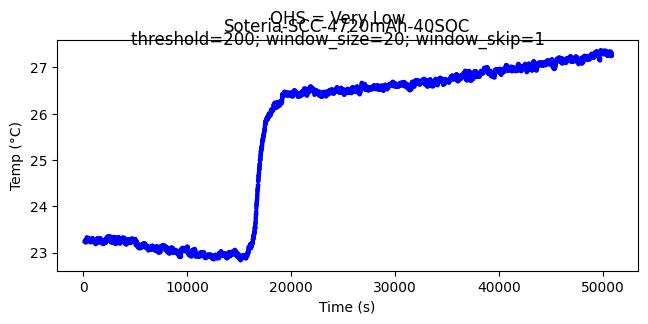

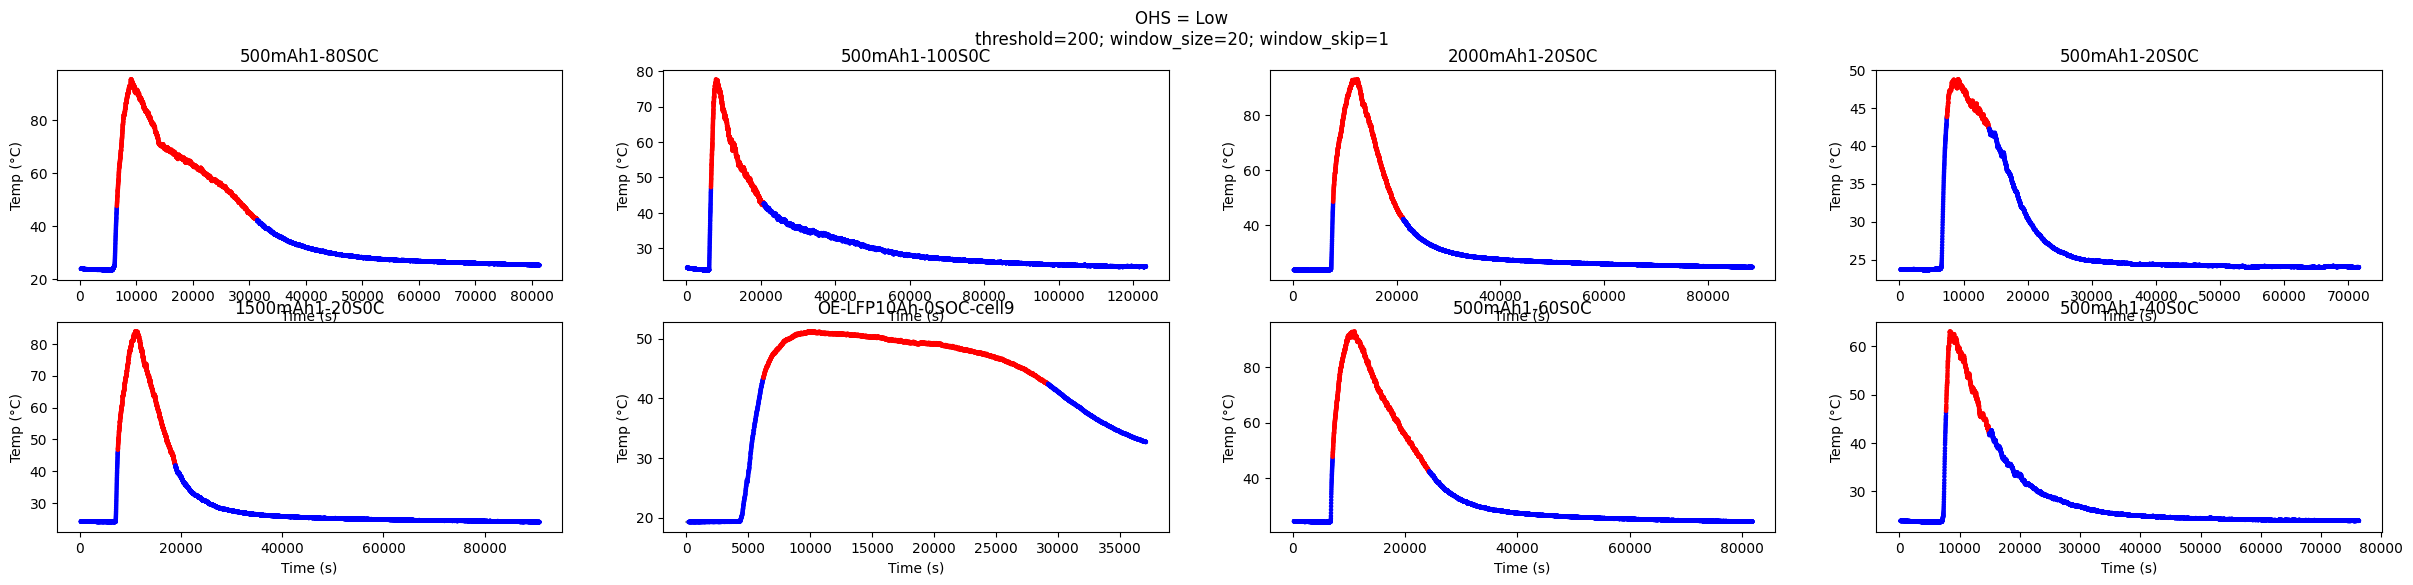

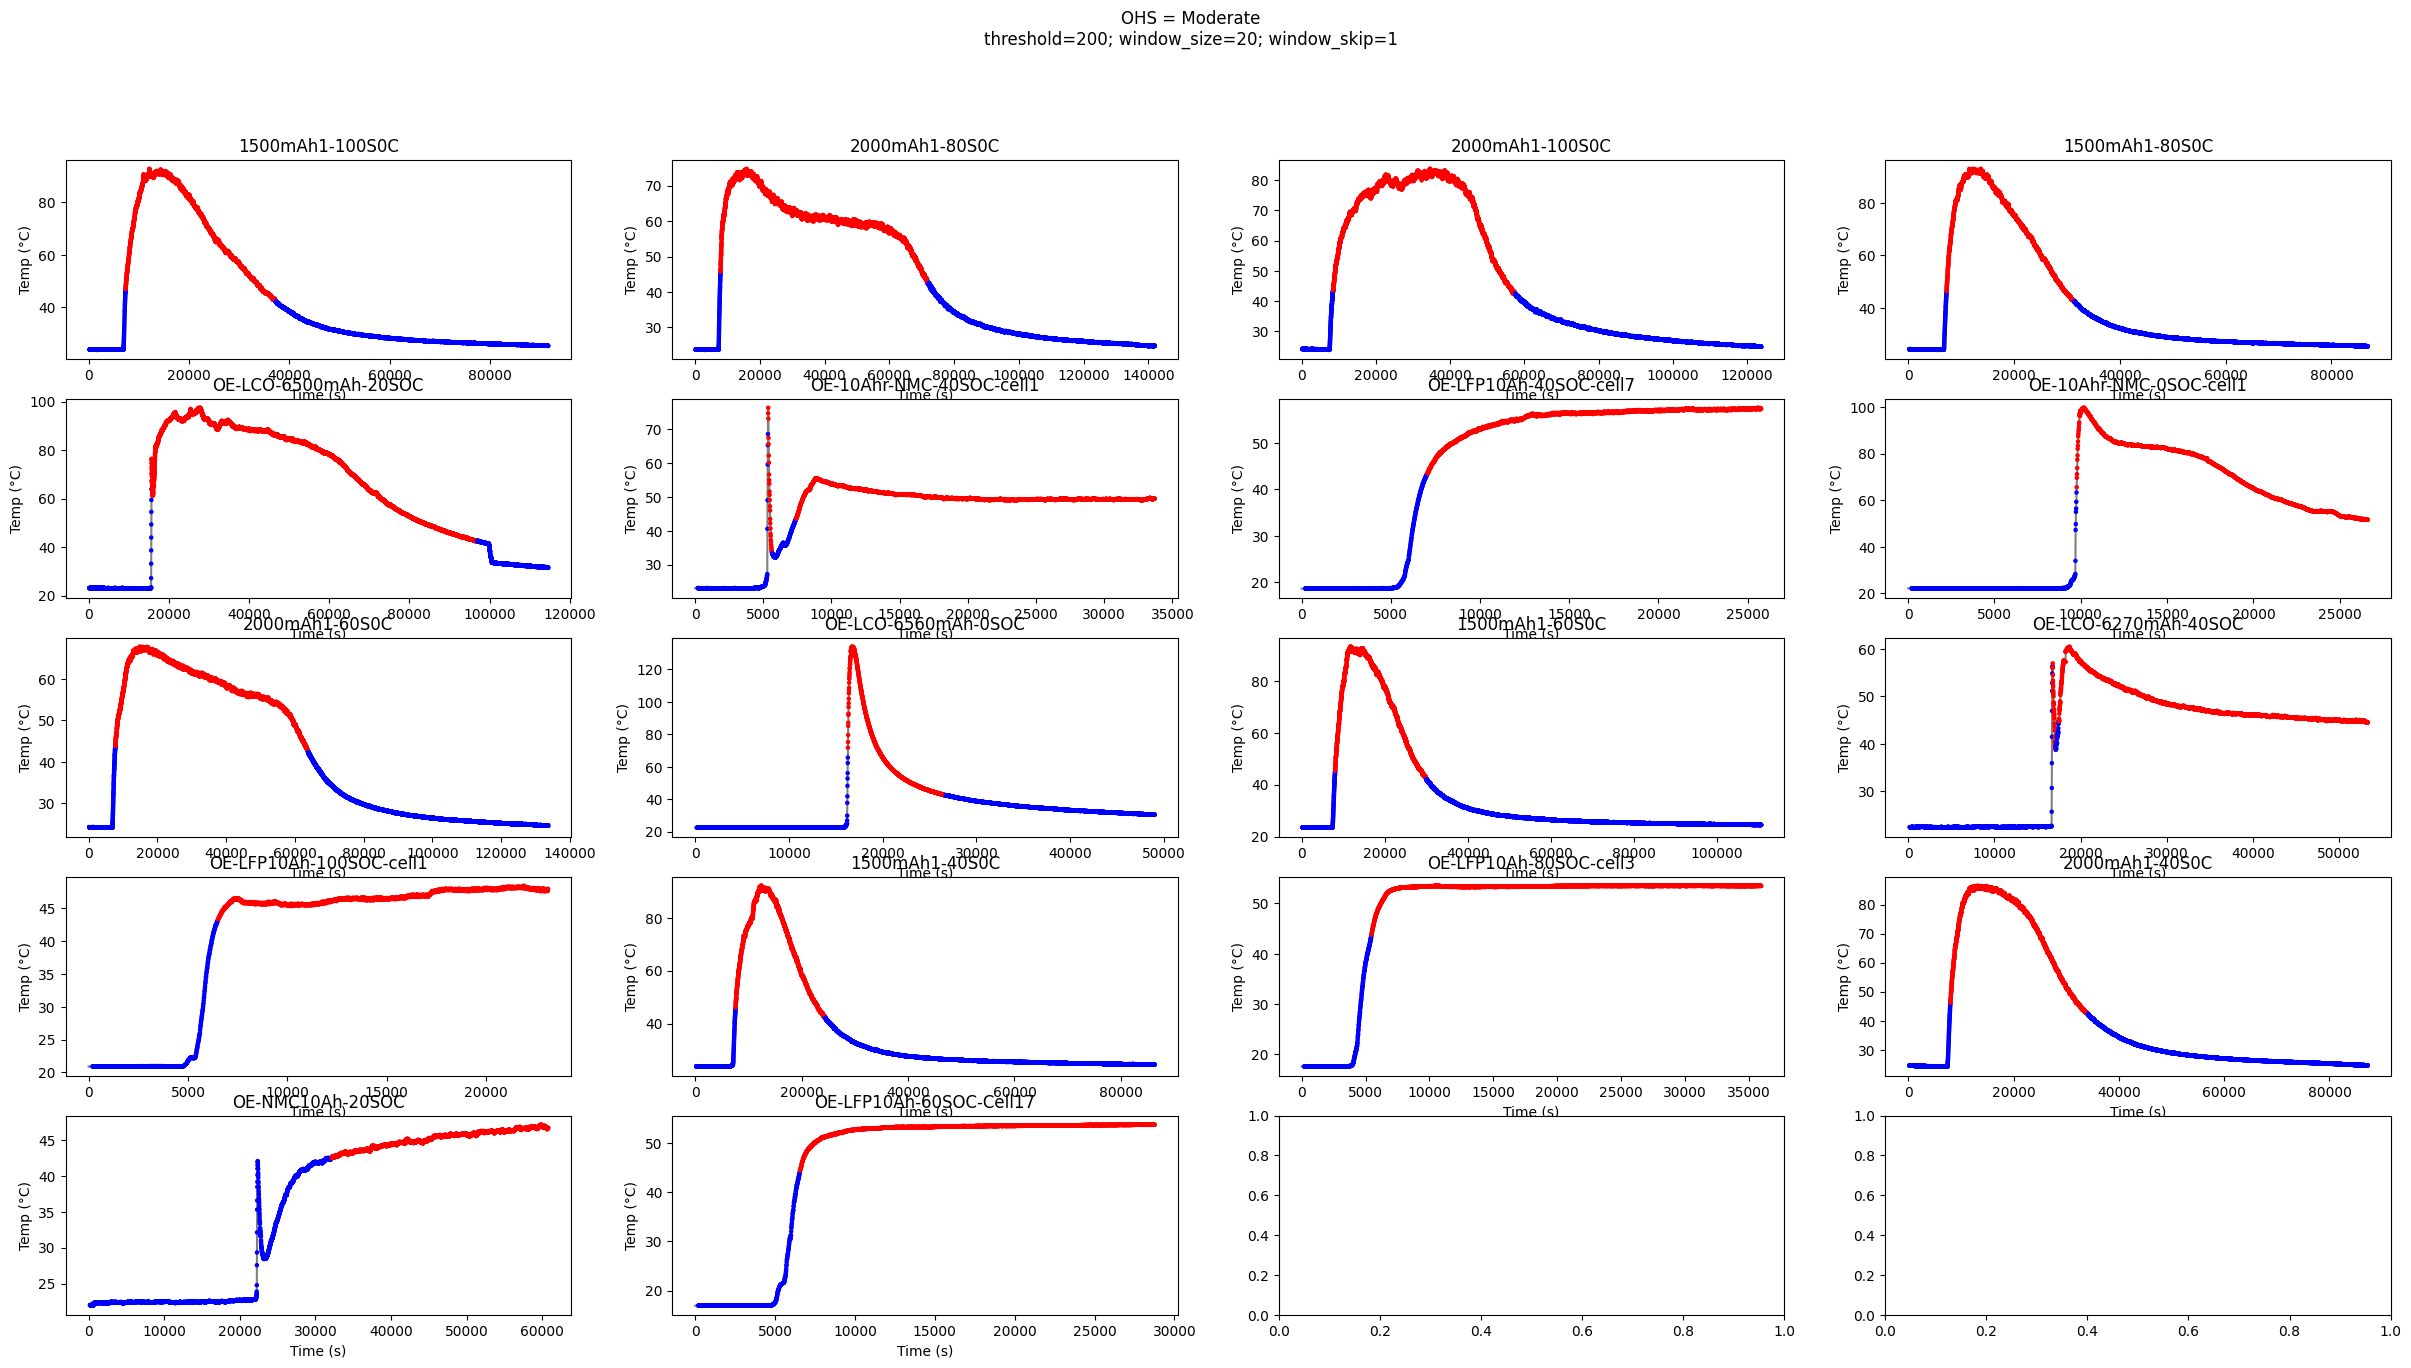

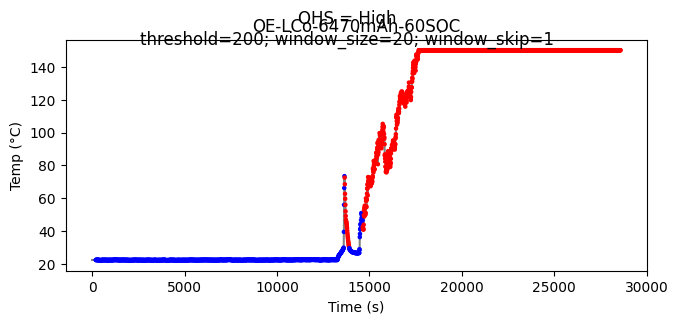

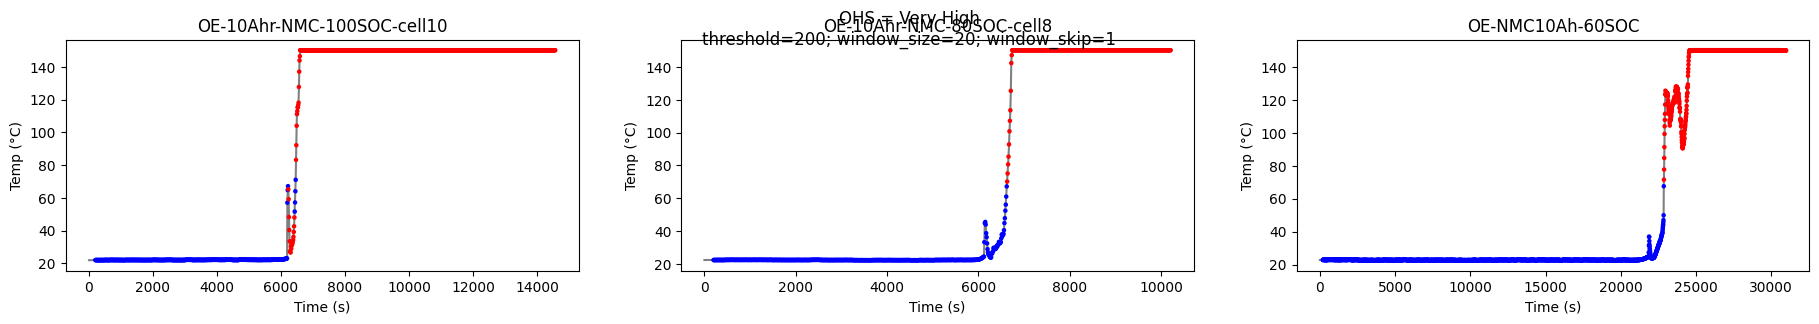

In [13]:
import math
from src.validation import *

for ohs in range(5):
    filenames = [f for f in ornl_findings[ornl_findings["ohs_int"]==ohs]["filenames"]]
    n = len(filenames)
    ncols = min(4, n)
    nrows = math.ceil(n/ncols)
    plot_multiple_evals_on_temp(
        err_file="results/reconstruction_errs/reconstruction_errs_unhealthy.json",
        title=f"OHS = {ohs_scores[ohs]}",
        filenames=filenames,
        threshold=THRESHOLD,
        ncols=ncols,
        # nrows=nrows,
        # figsize=(7.5*ncols, 3*nrows)
    )